In [1]:
from yaml import safe_load
import numpy as np
import sympy
from matplotlib import pyplot as plt
import pandas as pd
from scipy.stats import t
from formulaic import model_matrix
import seaborn as sns


sns.set_theme()

with open("config.yaml") as file:
    config = safe_load(file)

names = dict(
    Intercept="$I$",
    I="$I$",
    F=r"$\mathrm{Fr}$",
    p=r"$\phi$",
    b=r"$\beta$",
    c=r"$\varsigma$",
)

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    cols = {name: ":".join([names[k] for k in name.split(":")]) for name in m.columns}
    axim = sns.heatmap(m.rename(columns=cols), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

# Experiment matrix

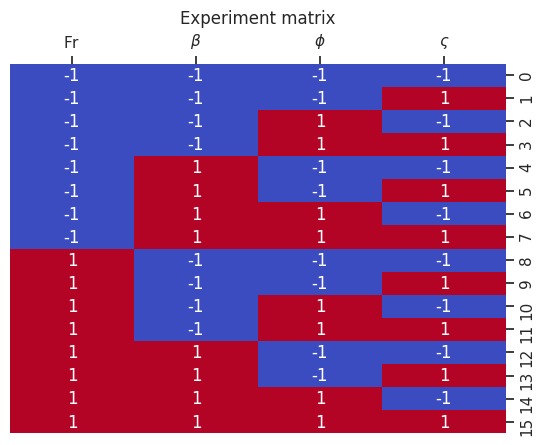

In [2]:
%matplotlib inline
E = pd.read_csv("matrix_experiment_standard.csv").rename(columns=dict(Fr="F"))
show_matrix(E)
plt.title("Experiment matrix")
plt.show()

# Model matrix

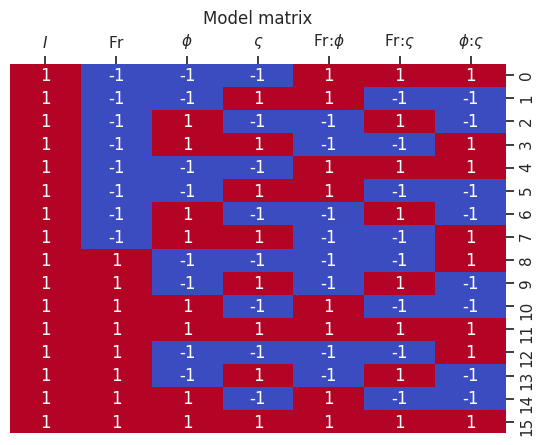

In [3]:
%matplotlib inline
M = model_matrix(
    "F + p + c + F:p + F:c + p:c",
    E
).rename(columns=dict(Intercept="I"))
M.to_csv("matrix_model.csv", index=False)

plt.figure()
show_matrix(M)
plt.title("Model matrix")
plt.show()

# Results

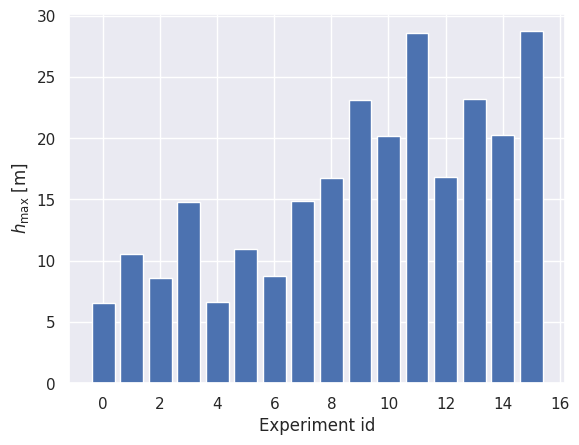

In [4]:
%matplotlib inline
hmax = np.loadtxt("hmax.csv", delimiter=",")
R = hmax / config["avalanche_depth"]
plt.bar(x=np.arange(R.size), height=hmax)
plt.xlabel("Experiment id")
plt.ylabel(r"$h_\mathrm{max}$ [m]")
plt.show()

# Effects

In [5]:
def half_effects(M, R):
    half_effects = np.linalg.solve(M.T @ M, M.T @ R)
    rel_effects = half_effects / half_effects[0]

    beta = 0.95
    alpha = 1-beta
    dof = M.shape[0] - M.shape[1]
    t_student = t.ppf(beta + alpha/2, dof)

    residue = R - M @ half_effects
    var_exp = residue.T @ residue /(dof)
    D = np.linalg.inv(M.T @ M)
    CI = t_student * np.sqrt((D @ np.ones(D.shape[1])) * var_exp)
    lower = half_effects - CI
    upper = half_effects + CI

    return pd.DataFrame(
        np.vstack((half_effects.T, CI.T, lower.T, upper.T, rel_effects.T)),
        index=["Half-effects", f"{beta:.0%} CI", "lower", "upper", "Relative"],
        columns=[f"x_{c.replace(':', '')}" for c in M.columns]
    )

In [6]:
%matplotlib inline
effect_df = half_effects(M, np.log(1+R))

effects = effect_df.iloc[0]
effects.index = effects.index.str.replace(":", "")

rel_effects = effect_df.iloc[-1]
rel_effects.index = effects.index.str.replace(":", "")

display(
  effect_df
  .T
  .round(3)
  .style.background_gradient(cmap="coolwarm", axis="columns")
  .format(precision=5)
)

,Half-effects,95% CI,lower,upper,Relative
x_I,1.38700,0.00500,1.38200,1.39100,1.00000
x_F,0.29400,0.00500,0.29000,0.29900,0.21200
x_p,0.09000,0.00500,0.08500,0.09500,0.06500
x_c,0.15200,0.00500,0.14800,0.15700,0.11000
x_Fp,-0.00900,0.00500,-0.01300,-0.00400,-0.00600
x_Fc,-0.01600,0.00500,-0.02100,-0.01100,-0.01200
x_pc,0.01300,0.00500,0.00800,0.01700,0.00900


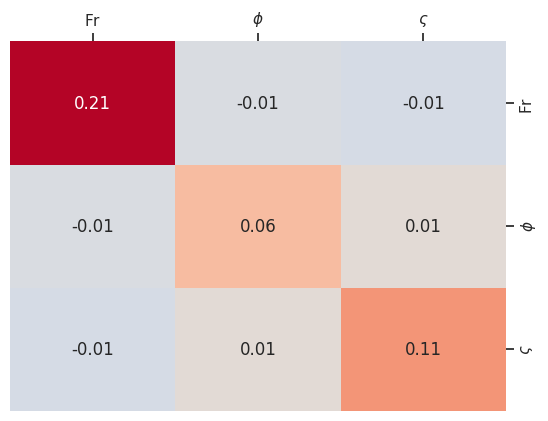

In [7]:
%matplotlib inline

M_main = M[M.columns[~M.columns.str.contains(":")]]

n_main = len(M_main.columns) - 1
effect_matrix = np.zeros((n_main, n_main), dtype=np.float16)

for i, f1 in enumerate(M_main.columns[1:]):
    for j, f2 in enumerate(M_main.columns[i+1:], start=i):
        if f1 == f2:
            f = f"x_{f1}"
        else:
            f = f"x_{f1}{f2}"
        if f in effects:
            effect_matrix[i, j] = rel_effects[f]
            effect_matrix[j, i] = rel_effects[f]

# effect_matrix = np.pad(effect_matrix, ((1, 0), (1, 0)), mode="constant", constant_values=0)
# effect_matrix[0, 0] = rel_effects["x_I"]

effect_matrix = pd.DataFrame(effect_matrix, columns=M_main.columns[1:])
vmax = np.abs(effect_matrix.drop(columns="I", errors="ignore")).max(axis=None)

show_matrix(effect_matrix, vmin=-vmax, vmax=vmax, yticklabels=[names[c] for c in M_main.columns[1:]], fmt=".2f")
plt.savefig("media/relative_effect_loglog.svg")
plt.show()

# ANOVA table

In [8]:
from statsmodels.api import stats #For ordinary least square "sm.OLS" 
from statsmodels.formula.api import ols #For ordinary least square "ols" not the same as above 
model = ols("1 ~ F + p + c + b", E)
result = model.fit()
anova_table = stats.anova_lm(result, typ=2)
display(anova_table)

,sum_sq,df,F,PR(>F)
F,2.773339e-32,1.0,0.064453,0.804274
p,4.437343e-31,1.0,1.031250,0.331681
c,1.972152e-31,1.0,0.458333,0.512390
b,3.081488e-33,1.0,0.007161,0.934080
Residual,4.733165e-30,11.0,NaN,NaN


# Predictions

In [9]:
variables = [np.prod([sympy.Symbol(f) for f in k[2:]], initial=1) for k in effects.index]
factors = [sympy.Symbol(k)*v for k, v in zip(effects.index, variables)]

predictor_analytical = sum(factors)
predictor = predictor_analytical.subs(effects.to_dict()).subs(dict(I=1))
predictor_main = predictor_analytical.subs({k: v if len(k)==3 else 0 for k, v in effects.items()}).subs(dict(I=1))

print("### Full expression ###")
print(predictor_analytical)
display(predictor_analytical)
print("### Substituting factors ###")
display(predictor)
print("### Ignoring interactions ###")
display(predictor_main)

### Full expression ###
F*c*x_Fc + F*p*x_Fp + F*x_F + I*x_I + c*p*x_pc + c*x_c + p*x_p


F*c*x_Fc + F*p*x_Fp + F*x_F + I*x_I + c*p*x_pc + c*x_c + p*x_p

### Substituting factors ###


-0.0161816433055888*F*c - 0.00859559761090284*F*p + 0.294305280674864*F + 0.0125736304352848*c*p + 0.152441513836016*c + 0.089871781084025*p + 1.38670072871875

### Ignoring interactions ###


0.294305280674864*F + 0.152441513836016*c + 0.089871781084025*p + 1.38670072871875

## Plotting surfaces and data

In [10]:
n = 100
x, y = np.meshgrid(np.linspace(-1, 1, num=n), np.linspace(-1, 1, num=n))
x, y = np.meshgrid(np.linspace(np.exp(-1), np.exp(1), num=n), np.linspace(np.exp(-1), np.exp(1), num=n))

def regression(debug=False, predictor=predictor, **kwargs):
    variables = [sympy.Symbol(c) for c in E.columns if c not in kwargs]
    p = predictor.subs(kwargs)
    if debug:
        print(variables)
        print(kwargs)
        display(predictor)
        display(p)
    return sympy.lambdify(variables, p)

def regression_main_factors(**kwargs):
    return regression(predictor=predictor_main, **kwargs)

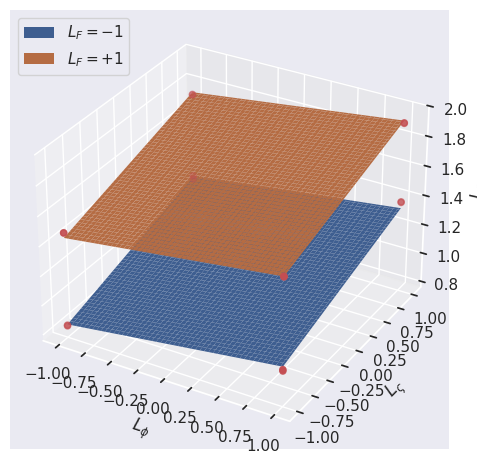

In [24]:
%matplotlib inline
#%matplotlib qt

x, y = np.meshgrid(np.linspace(E.p.min(), E.p.max(), num=n), np.linspace(E.c.min(), E.c.max(), num=n))

fig, axes = plt.subplots(subplot_kw=dict(projection="3d"), layout="tight")

axes.plot_surface(x, y, regression_main_factors(F=E.F.min(), b=0)(p=x, c=y), lw=0, label=r"$L_F=-1$")
axes.plot_surface(x, y, regression_main_factors(F=E.F.max(), b=0)(p=x, c=y), lw=0, label=r"$L_F=+1$")

axes.scatter(E["p"], E["c"], np.log(1+R), c="r")
axes.set_xlabel(r"$L_\phi$")
axes.set_ylabel(r"$L_\varsigma$")
axes.set_zlabel(r"$L_\eta$")
axes.legend(loc="upper left")
plt.savefig("media/planes_loglog.svg")
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_42591/2049245344.py:16: SyntaxWarning: invalid escape sequence '\e'
  axes.set_zlabel("$L_\eta$")


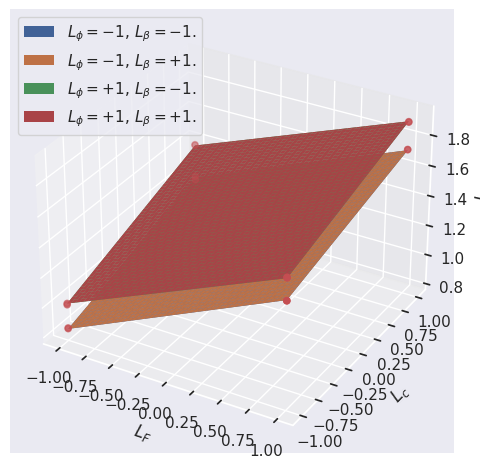

In [12]:
%matplotlib inline
#%matplotlib qt

x, y = np.meshgrid(np.linspace(E.F.min(), E.F.max(), num=n), np.linspace(E.c.min(), E.c.max(), num=n))

fig, axes = plt.subplots(subplot_kw=dict(projection="3d"), layout="tight")

axes.plot_surface(x, y, regression(p=E.p.min(), b=E.b.min())(F=x, c=y), lw=0, label=r"$L_\phi=-1,\,L_\beta=-1.$")
axes.plot_surface(x, y, regression(p=E.p.min(), b=E.b.max())(F=x, c=y), lw=0, label=r"$L_\phi=-1,\,L_\beta=+1.$")
axes.plot_surface(x, y, regression(p=E.p.max(), b=E.b.min())(F=x, c=y), lw=0, label=r"$L_\phi=+1,\,L_\beta=-1.$")
axes.plot_surface(x, y, regression(p=E.p.max(), b=E.b.max())(F=x, c=y), lw=0, label=r"$L_\phi=+1,\,L_\beta=+1.$")

axes.scatter(E["F"], E["c"], np.log(1+R), c="r")
axes.set_xlabel(r"$L_F$")
axes.set_ylabel(r"$L_c$")
axes.set_zlabel("$L_\eta$")
axes.legend(loc="upper left")
plt.show()

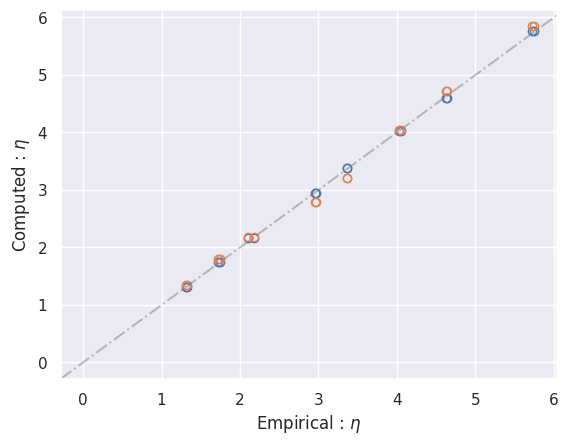

In [13]:
P = np.exp(regression()(**E))-1
Pm = np.exp(regression_main_factors()(**E))-1

np.savetxt("out_loglog.txt", P)
np.savetxt("out_loglog_m.txt", Pm)

plt.plot(R, P, 'o', mec="C0", mfc="none")
plt.plot(R, Pm, 'o', mec="C1", mfc="none")
plt.axline((0, 0), slope=1, ls="-.", alpha=0.5, color="gray")
plt.xlabel(r"Empirical : $\eta$")
plt.ylabel(r"Computed : $\eta$")
plt.show()

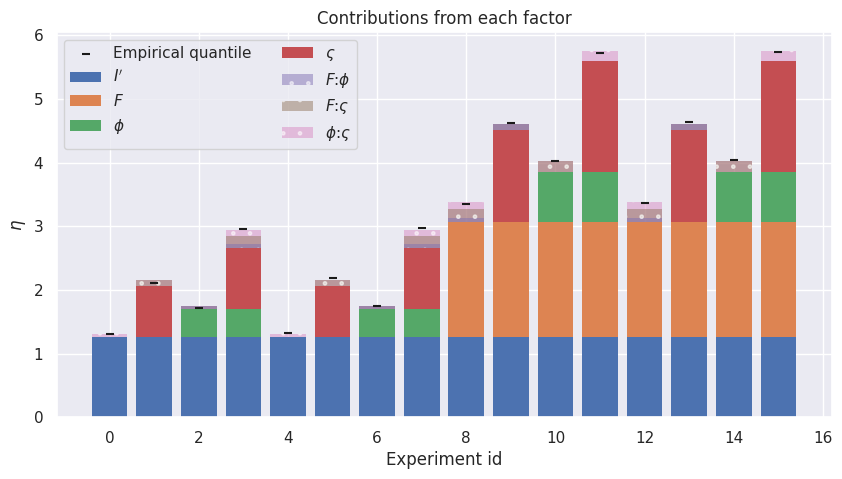

In [14]:
contributions = effects.values*M.values
base_effect = contributions.min(axis=0)
contributions -= base_effect
base_effect = base_effect.sum()
contributions = pd.DataFrame(contributions, columns=M.columns)
labels = dict(I="$I$", F="$F$", p=r"$\phi$", c=r"$\varsigma$", b=r"$\beta$")

plt.figure(figsize=(10, 5))
xa = np.arange(R.size)
plt.scatter(xa, R, label="Empirical quantile", marker="_", c="k", zorder=100)

plt.bar(xa, np.exp(base_effect)-1, label="$I'$", lw=0, zorder=2)
for i, c in enumerate(M.columns[1:], start=1):
    label = "".join([labels.get(l, ":") for l in c])
    plt.bar(
        xa,
        np.exp(base_effect+contributions.values[:, :i+1].sum(axis=1)) - 1,
        label=label,
        lw=0,
        zorder=2-i/len(M.columns),
        alpha=0.5 if ":" in label else 1,
        hatch="." if ":" in label else None
    )

plt.title("Contributions from each factor")
# plt.scatter(xa, R, zorder=1)
plt.xlabel("Experiment id")
plt.ylabel(r"$\eta$")
plt.legend(loc="upper left", ncols=2)
plt.savefig("media/contributions_loglog.svg")
plt.ylim(0, None)
plt.show()

/tmp/ipykernel_42591/1729836368.py:20: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(R, P_lin, 'o', ms=10, marker=r"$\ast$", label=f"Linear $R^2={r1*100:.2f}$%", zorder=4)
/tmp/ipykernel_42591/1729836368.py:21: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(R, P_lin_m, 'o', ms=10, marker=r"$\ast$", label=f"Linear : main effects $R^2={r2*100:.2f}$%", zorder=4)


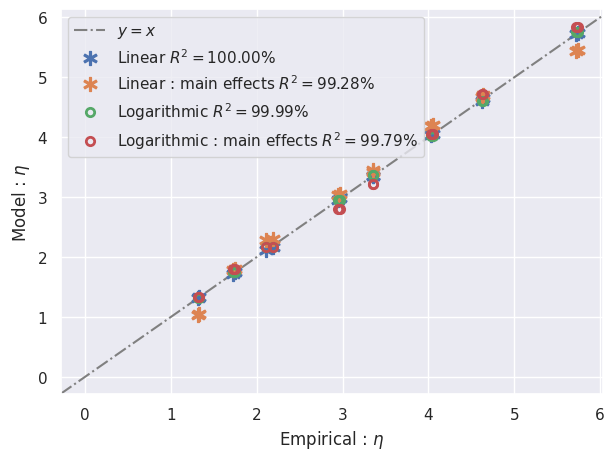

In [35]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import linregress
sns.set_theme()

R = np.loadtxt("hmax.csv", delimiter=",").T / 5
P_lin = np.loadtxt("out.txt")
P_log = np.loadtxt("out_loglog.txt")
P_lin_m = np.loadtxt("out_m.txt")
P_log_m = np.loadtxt("out_loglog_m.txt")

slope, intercept, r1, p1, stderr = linregress(R, P_lin)
slope, intercept, r2, p1, stderr = linregress(R, P_lin_m)
slope, intercept, r3, p1, stderr = linregress(R, P_log)
slope, intercept, r4, p1, stderr = linregress(R, P_log_m)

plt.figure(figsize=(7,5))
plt.axline((0, 0), slope=1, ls="-.", c="gray", label="$y=x$")
plt.plot(R, P_lin, 'o', ms=10, marker=r"$\ast$", label=f"Linear $R^2={r1*100:.2f}$%", zorder=4)
plt.plot(R, P_lin_m, 'o', ms=10, marker=r"$\ast$", label=f"Linear : main effects $R^2={r2*100:.2f}$%", zorder=4)
plt.plot(R, P_log, 'o', mfc="none", mew=2, label=f"Logarithmic $R^2={r3*100:.2f}$%", zorder=5)
plt.plot(R, P_log_m, 'o', mfc="none", mew=2, label=f"Logarithmic : main effects $R^2={r4*100:.2f}$%", zorder=5)
plt.xlabel(r"Empirical : $\eta$")
plt.ylabel(r"Model : $\eta$")
plt.legend()
plt.savefig("media/qq_plot.svg")
plt.show()

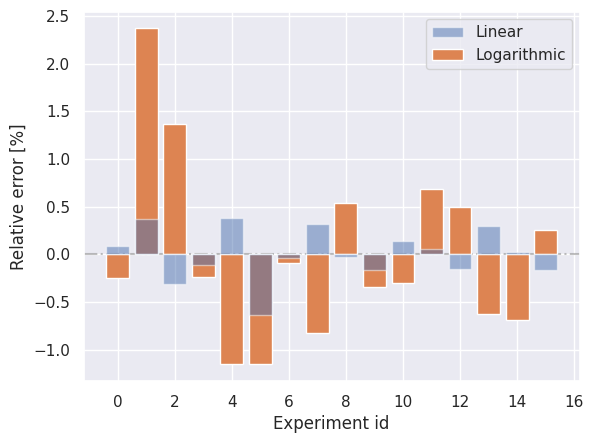

In [16]:
xa = np.arange(R.size)
plt.bar(xa, (P_lin-R)/R*100, label="Linear", zorder=6, alpha=0.5)
plt.bar(xa, (P_log-R)/R*100, label="Logarithmic", zorder=5)
plt.axline((0, 0), slope=0, ls="-.", color="gray", alpha=0.5)
plt.xlabel("Experiment id")
plt.ylabel(r"$\frac{h_\mathrm{max}^\mathrm{predicted} - h_\mathrm{max}^\mathrm{experiment}}{h_\mathrm{max}^\mathrm{experiment}}$")
plt.ylabel("Relative error [%]")
plt.legend()
plt.savefig("media/relative_error.svg")
plt.show()

In [67]:
bounds = pd.DataFrame(dict(
    F=(2, 5),
    p=(0.5, 1.5),
    c=(1/(config["avalanche_depth"]*0.9995), 1/(config["avalanche_depth"]*1.0005)),
    # b=(1, 2)
))
L = np.log(bounds.max(axis="rows") / bounds.min(axis="rows"))
meffects = effects[[c for c in effects.index[1:] if len(c.strip("x_")) == 1]]
display(meffects)
display(L)
display(meffects.values / L.values)

x_F    0.294305
x_p    0.089872
x_c    0.152442
Name: Half-effects, dtype: float64

F    0.916291
p    1.098612
c    0.001000
dtype: float64

array([3.21192030e-01, 8.18048205e-02, 1.52441501e+02])